# 🎓 Entrenamiento de Proactive Forest para Predicción de Abandono Estudiantil

**Federated Proactive Forest - Dataset Students Dropout**

Este notebook implementa el entrenamiento completo de un modelo **Proactive Forest** utilizando el dataset de abandono estudiantil, con una arquitectura modular separada por responsabilidades.

## 📋 Contenido
1. [Configuración del Entorno](#1-configuración-del-entorno)
2. [Carga y Preparación de Datos](#2-carga-y-preparación-de-datos)
3. [Arquitectura del Sistema](#3-arquitectura-del-sistema)
4. [Entrenamiento del Modelo](#4-entrenamiento-del-modelo)
5. [Evaluación del Modelo](#5-evaluación-del-modelo)
6. [Conclusiones](#6-conclusiones)

---
## 1️⃣ Configuración del Entorno

### Responsabilidad: Gestión de dependencias y configuración inicial

En esta sección importamos todas las librerías necesarias y configuramos el entorno de trabajo.

In [46]:
# ============================================
# 📦 IMPORTACIÓN DE LIBRERÍAS
# ============================================

# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para machine learning (scikit-learn)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    confusion_matrix,
    classification_report
)

# Librerías para gestión de tiempo
import time
import sys

# Configurar estilo de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


---
## 2️⃣ Carga y Preparación de Datos

### Responsabilidad: Data Loading y Preprocessing

Esta sección se encarga de:
- Cargar el dataset desde el archivo CSV
- Realizar análisis exploratorio básico
- Separar características y variable objetivo
- Codificar labels categóricos
- Escalar las características
- Dividir en conjuntos de entrenamiento y prueba

In [47]:
# ============================================
# 📊 CARGA DEL DATASET
# ============================================

# Cargar el dataset de abandono estudiantil
# El separador es ';' porque el CSV usa punto y coma como delimitador
df = pd.read_csv('../../../data/students_dropout.csv', sep=';')

# Mostrar información general del dataset
print("=" * 80)
print("📊 INFORMACIÓN DEL DATASET")
print("=" * 80)
print(f"• Número de muestras: {df.shape[0]:,}")
print(f"• Número de características: {df.shape[1]}")
print(f"• Columnas: {list(df.columns)}")

📊 INFORMACIÓN DEL DATASET
• Número de muestras: 4,424
• Número de características: 37
• Columnas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd


📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)


          Cantidad  Porcentaje (%)
Target                            
Graduate      2209       49.932188
Dropout       1421       32.120253
Enrolled       794       17.947559


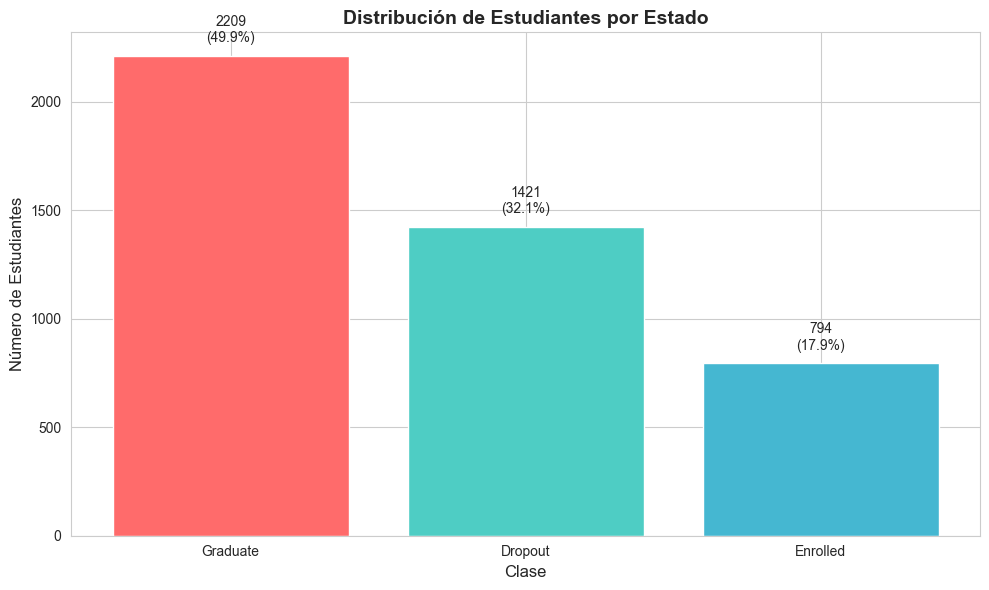


⚠️ Nota: El dataset presenta desbalanceo de clases


In [48]:
# ============================================
# 📈 ANÁLISIS DE LA VARIABLE OBJETIVO
# ============================================

# La variable 'Target' indica el estado del estudiante:
# - Dropout: Abandonó los estudios
# - Enrolled: Continúa matriculado
# - Graduate: Se graduó

print("\n" + "=" * 80)
print("📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)")
print("=" * 80)

# Calcular distribución absoluta y relativa
target_counts = df['Target'].value_counts()
target_percent = df['Target'].value_counts(normalize=True) * 100

# Crear DataFrame resumen
target_summary = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_percent
})

print(target_summary.to_string())

# Visualizar distribución
plt.figure(figsize=(10, 6))
bars = plt.bar(target_summary.index, target_summary['Cantidad'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Número de Estudiantes', fontsize=12)
plt.title('Distribución de Estudiantes por Estado', fontsize=14, fontweight='bold')

# Añadir etiquetas con valores
for i, (bar, count) in enumerate(zip(bars, target_summary['Cantidad'])):
    class_name = target_summary.index[i]
    percentage = target_percent[class_name]
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n⚠️ Nota: El dataset presenta desbalanceo de clases")

In [49]:
# ============================================
# 🔧 PREPARACIÓN DE CARACTERÍSTICAS Y TARGET
# ============================================

# Separar las características (X) de la variable objetivo (y)
target_column = 'Target'
feature_columns = [col for col in df.columns if col != target_column]

# Extraer matrices de datos
X = df[feature_columns].values.astype(np.float64)
y = df[target_column].values

# Codificar las etiquetas categóricas a valores numéricos
# LabelEncoder transforma: ['Dropout', 'Enrolled', 'Graduate'] -> [0, 1, 2]
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)

print("=" * 80)
print("✅ CODIFICACIÓN DE CLASES")
print("=" * 80)
for i, class_name in enumerate(class_names):
    print(f"   Clase {i}: {class_name}")

print(f"\n📊 Dimensiones de X: {X.shape}")
print(f"📊 Dimensiones de y: {y_encoded.shape}")

✅ CODIFICACIÓN DE CLASES
   Clase 0: Dropout
   Clase 1: Enrolled
   Clase 2: Graduate

📊 Dimensiones de X: (4424, 36)
📊 Dimensiones de y: (4424,)


In [50]:
# ============================================
# 📈 DIVISIÓN TRAIN/TEST Y ESCALADO
# ============================================

# Dividir el dataset en entrenamiento (80%) y prueba (20%)
# stratify=y_encoded asegura que la distribución de clases se mantenga
# random_state=42 garantiza reproducibilidad de los resultados
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

# Escalar las características usando StandardScaler
# Esto transforma las features para que tengan media=0 y desviación=1
# IMPORTANTE: El scaler se ajusta SOLO con train para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("📊 DIVISIÓN DE DATOS")
print("=" * 80)
print(f"• Train: {X_train_scaled.shape[0]:,} muestras ({X_train_scaled.shape[0]/len(X)*100:.1f}%)")
print(f"• Test:  {X_test_scaled.shape[0]:,} muestras ({X_test_scaled.shape[0]/len(X)*100:.1f}%)")
print(f"\n✅ Escalado completado (media≈0, std≈1)")

📊 DIVISIÓN DE DATOS
• Train: 3,539 muestras (80.0%)
• Test:  885 muestras (20.0%)

✅ Escalado completado (media≈0, std≈1)


---
## 3️⃣ Arquitectura del Sistema

### Responsabilidad: Importación de Componentes FL

El framework **Federated Proactive Forest** se compone de:

1. **FLEXOrchestrator**: Orquesta el entrenamiento federado entre clientes
2. **DatasetSplit**: Gestiona la división y distribución de datos
3. **AggregationFactory**: Fábrica de estrategias de agregación (S1-S7)

Las 7 estrategias disponibles son:
- **S1**: Simple Pool (todos los árboles)
- **S2**: Global Accuracy (selección por accuracy global)
- **S3**: Global F1-Score (selección por F1 global)
- **S4**: Global F1 + PCD (F1 con diversidad)
- **S5**: Per-Client Accuracy (selección por cliente)
- **S6**: Per-Client F1-Score (selección por cliente)
- **S7**: Per-Client F1 + PCD (selección por cliente con diversidad)

In [51]:
# ============================================
# 🏗️ IMPORTACIÓN DE COMPONENTES DEL FRAMEWORK
# ============================================

# Añadir el directorio raíz al path para importar módulos
sys.path.append('../../../')

# Importar componentes principales del framework Federated Proactive Forest
from src.application.fl_orchestrator import FLEXOrchestrator, DatasetSplit
from src.domain.aggregation.aggregation_factory import AggregationFactory

print("✅ Componentes del framework importados correctamente")
print("\n📦 Componentes disponibles:")
print("   • FLEXOrchestrator - Orquestación del entrenamiento federado")
print("   • DatasetSplit - Gestión de división de datos")
print("   • AggregationFactory - Fábrica de estrategias de agregación")

✅ Componentes del framework importados correctamente

📦 Componentes disponibles:
   • FLEXOrchestrator - Orquestación del entrenamiento federado
   • DatasetSplit - Gestión de división de datos
   • AggregationFactory - Fábrica de estrategias de agregación


In [52]:
# ============================================
# ⚙️ CONFIGURACIÓN DEL ENTRENAMIENTO
# ============================================

# Diccionario de configuración con todos los hiperparámetros
CONFIG = {
    # Configuración de clientes federados
    'n_clients': 3,              # Número de clientes en el sistema federado
    'distribution': 'iid',       # Distribución: 'iid' (independiente e idéntica)
    
    # Configuración del modelo Proactive Forest
    'n_estimators': 100,         # Número máximo de árboles por cliente
    'alpha_pf': 0.1,            # Parámetro α de Proactive Forest (controla early stopping)
    
    # Configuración de ejecución
    'verbose': True,            # Mostrar logs detallados durante entrenamiento
    'seed': 42,                  # Seed para reproducibilidad
    
    # Configuración de estrategias (para S4 y S7 que usan PCD)
    'aggregation': {
        'f1_weight': 0.5,        # Peso para F1-Score en ranking
        'pcd_weight': 0.5        # Peso para diversidad (PCD) en ranking
    }
}

# Estrategia a utilizar en este entrenamiento
# Cambiar este valor para probar diferentes estrategias (S1-S7)
SELECTED_STRATEGY = 'S1'  # 📝 MODIFICAR AQUÍ PARA CAMBIAR ESTRATEGIA

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 80)
print(f"📊 Número de clientes: {CONFIG['n_clients']}")
print(f"📈 Distribución de datos: {CONFIG['distribution']}")
print(f"🌳 Árboles por cliente: {CONFIG['n_estimators']}")
print(f"🎯 Parámetro α (Proactive Forest): {CONFIG['alpha_pf']}")
print(f"📋 Estrategia de agregación: {SELECTED_STRATEGY}")
print(f"🌱 Random seed: {CONFIG['seed']}")

⚙️ CONFIGURACIÓN DEL ENTRENAMIENTO
📊 Número de clientes: 3
📈 Distribución de datos: iid
🌳 Árboles por cliente: 100
🎯 Parámetro α (Proactive Forest): 0.1
📋 Estrategia de agregación: S1
🌱 Random seed: 42


In [53]:
# ============================================
# 📦 CREACIÓN DEL DATASET SPLIT
# ============================================

# DatasetSplit es un objeto que encapsula toda la información del dataset
# necesaria para el entrenamiento federado
dataset_split = DatasetSplit(
    X_train=X_train_scaled,           # Features de entrenamiento (escaladas)
    X_test=X_test_scaled,             # Features de prueba (escaladas)
    y_train=y_train,                  # Labels de entrenamiento
    y_test=y_test,                    # Labels de prueba
    feature_names=feature_columns,    # Nombres de las características
    class_names=class_names,          # Nombres de las clases
    dataset_name='Students Dropout'   # Nombre identificador del dataset
)

print("✅ DatasetSplit creado exitosamente")
print(f"   Dataset: {dataset_split.dataset_name}")
print(f"   Features: {len(dataset_split.feature_names)}")
print(f"   Clases: {dataset_split.class_names}")

✅ DatasetSplit creado exitosamente
   Dataset: Students Dropout
   Features: 36
   Clases: ['Dropout', 'Enrolled', 'Graduate']


---
## 4️⃣ Entrenamiento del Modelo

### Responsabilidad: Entrenamiento Federado

El proceso de entrenamiento sigue estos pasos:

1. **Inicialización**: El orquestador distribuye los datos entre los clientes
2. **Entrenamiento local**: Cada cliente entrena sus árboles localmente
3. **Selección de árboles**: La estrategia selecciona los mejores árboles
4. **Agregación**: Se construye el bosque global
5. **Evaluación**: Se evalúa el modelo resultante

In [54]:
# ============================================
# 🚀 INICIO DEL ENTRENAMIENTO
# ============================================

print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DE PROACTIVE FOREST")
print("=" * 80)
print(f"\n⏳ Tiempo de inicio: {time.strftime('%H:%M:%S')}")
print("\nProceso en curso...\n")

# Registrar tiempo de inicio
start_time = time.time()

# 1. Preparar la configuración con la estrategia seleccionada
# FLEXOrchestrator requiere un diccionario config con todos los parámetros
config = CONFIG.copy()
config['strategy'] = SELECTED_STRATEGY  # Añadir la estrategia a la configuración

# 2. Crear el orquestador FL usando el método from_config
# from_config inicializa el orquestador con todos los parámetros necesarios
orchestrator = FLEXOrchestrator.from_config(config)

# 3. Configurar la federación con el dataset
# setup_federation distribuye los datos entre los clientes según la distribución especificada
orchestrator.setup_federation(dataset_split, seed=CONFIG['seed'])

# 4. Ejecutar la ronda federada
# run_federated_round ejecuta TODO el pipeline:
# - Distribución de datos a clientes
# - Entrenamiento local de árboles
# - Selección y agregación de árboles (usando la estrategia configurada)
# - Evaluación del modelo global
results = orchestrator.run_federated_round()

# Registrar tiempo final
end_time = time.time()
execution_time = end_time - start_time

print(f"\n✅ Entrenamiento completado en {execution_time:.2f} segundos")
print(f"⏳ Tiempo de finalización: {time.strftime('%H:%M:%S', time.localtime(end_time))}")

🚀 INICIANDO ENTRENAMIENTO DE PROACTIVE FOREST

⏳ Tiempo de inicio: 12:22:44

Proceso en curso...

  Árbol 1 | acc=0.6441
  Árbol 2 | acc=0.6441
  Árbol 3 | acc=0.6441
  Árbol 4 | acc=0.6271
  Árbol 5 | acc=0.6186
  [CPF] No converge, siguiente episodio=6
  [CPF] Árboles construidos=5, próximo episodio=6
  ----------------------------------------
  Árbol 6 | acc=0.6271
  Árbol 7 | acc=0.6653
  Árbol 8 | acc=0.6780
  Árbol 9 | acc=0.6144
  Árbol 10 | acc=0.6483
  Árbol 11 | acc=0.6356
  [CPF] No converge, siguiente episodio=7
  [CPF] Árboles construidos=11, próximo episodio=7
  ----------------------------------------
  Árbol 12 | acc=0.6144
  Árbol 13 | acc=0.6186
  Árbol 14 | acc=0.6186
  Árbol 15 | acc=0.6314
  Árbol 16 | acc=0.6949
  Árbol 17 | acc=0.5847
  Árbol 18 | acc=0.6525
  [CPF] No converge, siguiente episodio=8
  [CPF] Árboles construidos=18, próximo episodio=8
  ----------------------------------------
  Árbol 19 | acc=0.6568
  Árbol 20 | acc=0.6610
  Árbol 21 | acc=0.6186


In [55]:
# ============================================
# 📊 RESUMEN DEL ENTRENAMIENTO
# ============================================

# Mostrar información detallada del entrenamiento completado
print("=" * 80)
print("📊 RESUMEN DEL ENTRENAMIENTO")
print("=" * 80)

# Información de árboles entrenados por cliente
# Se obtiene de selected_ids que contiene los índices de árboles seleccionados por cliente
print("\n🌳 ÁRBOLES ENTRENADOS POR CLIENTE:")
print("-" * 80)
total_trees = 0
for client_id in results.client_ids:
    # selected_ids contiene los índices de árboles seleccionados para cada cliente
    n_trees = len(results.selected_ids.get(client_id, []))
    total_trees += n_trees
    print(f"   • {client_id}: {n_trees} árboles seleccionados")
print(f"   TOTAL: {total_trees} árboles en el bosque global")

# Información de árboles seleccionados (porcentaje)
print(f"\n📋 ÁRBOLES SELECCIONADOS (Estrategia: {results.strategy_id}):")
print("-" * 80)
# Nota: Los árboles entrenados originalmente pueden ser más que los seleccionados
# La estrategia determina cuántos árboles se seleccionan del total entrenado
for client_id, indices in results.selected_ids.items():
    n_selected = len(indices)
    # El total entrenado no está directamente disponible, mostramos solo los seleccionados
    print(f"   • {client_id}: {n_selected} árboles seleccionados")

# Información del bosque global
print(f"\n🌲 BOSQUE GLOBAL:")
print("-" * 80)
print(f"   • Tamaño final: {results.n_trees_global} árboles")
print(f"   • Costo de comunicación: {results.communication_cost:.2f} KB")
print(f"   • Accuracy Global: {results.global_accuracy:.4f}")
print(f"   • F1-Score Global: {results.global_macro_f1:.4f}")

📊 RESUMEN DEL ENTRENAMIENTO

🌳 ÁRBOLES ENTRENADOS POR CLIENTE:
--------------------------------------------------------------------------------
   • client_0: 33 árboles seleccionados
   • client_1: 24 árboles seleccionados
   • client_2: 16 árboles seleccionados
   TOTAL: 73 árboles en el bosque global

📋 ÁRBOLES SELECCIONADOS (Estrategia: S1):
--------------------------------------------------------------------------------
   • client_0: 33 árboles seleccionados
   • client_1: 24 árboles seleccionados
   • client_2: 16 árboles seleccionados

🌲 BOSQUE GLOBAL:
--------------------------------------------------------------------------------
   • Tamaño final: 73 árboles
   • Costo de comunicación: 0.01 KB
   • Accuracy Global: 0.7537
   • F1-Score Global: 0.6502


---
## 5️⃣ Evaluación del Modelo

### Responsabilidad: Evaluación y Métricas

Esta sección calcula y visualiza las métricas de evaluación:

1. **Matriz de Confusión**: Muestra aciertos y errores por clase
2. **Accuracy**: Porcentaje de predicciones correctas
3. **Precisión**: De los que predije como clase X, ¿cuántos realmente son X?
4. **Recall**: De los que son clase X, ¿cuántos logré identificar?
5. **F1-Score**: Media armónica entre Precisión y Recall

In [56]:
# ============================================
# 📈 MÉTRICAS GLOBALES
# ============================================

# Las métricas globales se calculan sobre el bosque global completo
# evaluado en el conjunto de test

print("=" * 80)
print("🌍 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

# Extraer métricas del objeto results
global_accuracy = results.global_accuracy
global_f1 = results.global_macro_f1
global_precision = results.global_report.macro_precision  # Note: typo in original code
global_recall = results.global_report.macro_recall

print(f"\n🎯 Accuracy:   {global_accuracy:.4f} ({global_accuracy*100:.2f}%)")
print(f"📊 F1-Score:   {global_f1:.4f} ({global_f1*100:.2f}%)")
print(f"📈 Precisión:  {global_precision:.4f} ({global_precision*100:.2f}%)")
print(f"📉 Recall:     {global_recall:.4f} ({global_recall*100:.2f}%)")

# Interpretación de métricas
print("\n" + "=" * 80)
print("📖 INTERPRETACIÓN DE MÉTRICAS")
print("=" * 80)
print(f"""
• Accuracy ({global_accuracy:.4f}): De todas las predicciones, el {global_accuracy*100:.2f}% fueron correctas.

• F1-Score ({global_f1:.4f}): Media armónica entre precisión y recall.
  Un valor de {global_f1:.4f} indica un balance {'bueno' if global_f1 > 0.7 else 'regular' if global_f1 > 0.5 else 'mejorable'}.

• Precisión ({global_precision:.4f}): Cuando el modelo predice una clase, acierta el {global_precision*100:.2f}% de las veces.

• Recall ({global_recall:.4f}): El modelo identifica correctamente al {global_recall*100:.2f}% de los estudiantes de cada clase.
""")

🌍 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy:   0.7537 (75.37%)
📊 F1-Score:   0.6502 (65.02%)
📈 Precisión:  0.6891 (68.91%)
📉 Recall:     0.6457 (64.57%)

📖 INTERPRETACIÓN DE MÉTRICAS

• Accuracy (0.7537): De todas las predicciones, el 75.37% fueron correctas.

• F1-Score (0.6502): Media armónica entre precisión y recall.
  Un valor de 0.6502 indica un balance regular.

• Precisión (0.6891): Cuando el modelo predice una clase, acierta el 68.91% de las veces.

• Recall (0.6457): El modelo identifica correctamente al 64.57% de los estudiantes de cada clase.



In [57]:
# ============================================
# 📊 MATRIZ DE CONFUSIÓN
# ============================================

# La matriz de confusión muestra:
# - Filas: Clase real (verdadera)
# - Columnas: Clase predicha por el modelo
# - Diagonal principal: Aciertos
# - Fuera de diagonal: Errores

# Extraer predicciones globales del conjunto de test
y_pred_global = results.global_predictions

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_global)

# Crear figura con dos subplots: matriz absoluta y normalizada
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# === SUBPLOT 1: Matriz de Confusión Absoluta ===
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            ax=axes[0], annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_xlabel('Clase Predicha', fontsize=12)
axes[0].set_ylabel('Clase Real', fontsize=12)
axes[0].set_title('Matriz de Confusión (Valores Absolutos)', fontsize=13, fontweight='bold')

# === SUBPLOT 2: Matriz de Confusión Normalizada ===
# Normalizar por filas (por clase real) para ver porcentajes de acierto/error
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_xlabel('Clase Predicha', fontsize=12)
axes[1].set_ylabel('Clase Real', fontsize=12)
axes[1].set_title('Matriz de Confusión (Porcentajes por Clase Real)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir interpretación
print("=" * 80)
print("📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN")
print("=" * 80)
print("""
La matriz muestra:
• Filas = Clase REAL (verdadera)
• Columnas = Clase PREDICHA por el modelo
• Diagonal principal = Aciertos (verde/azul intenso)
• Fuera de diagonal = Errores de clasificación

Ejemplo de lectura:
• Si en la fila 'Dropout' y columna 'Dropout' hay 85%, significa que
  el modelo identifica correctamente el 85% de los estudiantes que abandonaron.
""")

ValueError: Mix of label input types (string and number)

In [ ]:
# ============================================
# 📊 REPORTE DE CLASIFICACIÓN POR CLASE
# ============================================

# El classification_report de sklearn muestra precisión, recall y F1
# para CADA clase individualmente, no solo el promedio macro

print("=" * 80)
print("📊 REPORTE DE CLASIFICACIÓN POR CLASE")
print("=" * 80)
print("\nMétricas detalladas para cada clase:\n")

# Generar reporte de clasificación
report = classification_report(
    y_test, 
    y_pred_global, 
    target_names=class_names,
    digits=4,
    output_dict=False  # Imprimir directamente como string
)

print(report)

# Imprimir interpretación
print("=" * 80)
print("📖 INTERPRETACIÓN DEL REPORTE POR CLASE")
print("=" * 80)
print("""
Para cada clase se muestra:
• Precision: De los predichos como esta clase, ¿cuántos realmente lo son?
• Recall: De los que realmente son esta clase, ¿cuántos identificó?
• F1-Score: Media armónica (balance) entre precision y recall
• Support: Número de muestras de esta clase en el test

Promedios:
• macro avg: Promedio simple de las métricas de todas las clases
• weighted avg: Promedio ponderado por el support de cada clase
""")

In [ ]:
# ============================================
# 📈 VISUALIZACIÓN DE MÉTRICAS POR CLASE
# ============================================

# Calcular métricas por clase individualmente para visualización
metrics_per_class = {
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for i, class_name in enumerate(class_names):
    # Calcular métricas para esta clase específica (one-vs-rest)
    precision = precision_score(y_test, y_pred_global, labels=[i], average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred_global, labels=[i], average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_global, labels=[i], average='macro', zero_division=0)
    
    metrics_per_class['Precision'].append(precision)
    metrics_per_class['Recall'].append(recall)
    metrics_per_class['F1-Score'].append(f1)

# Crear DataFrame para visualización
metrics_df = pd.DataFrame(metrics_per_class, index=class_names)

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# === SUBPLOT 1: Barras agrupadas por métrica ===
x = np.arange(len(class_names))
width = 0.25

bars1 = axes[0].bar(x - width, metrics_per_class['Precision'], width, 
                    label='Precisión', color='#FF6B6B')
bars2 = axes[0].bar(x, metrics_per_class['Recall'], width, 
                    label='Recall', color='#4ECDC4')
bars3 = axes[0].bar(x + width, metrics_per_class['F1-Score'], width, 
                    label='F1-Score', color='#45B7D1')

axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Puntuación', fontsize=12)
axes[0].set_title('Métricas por Clase', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_ylim(0, 1.0)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Añadir etiquetas de valor en las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# === SUBPLOT 2: Radar chart ===
from math import pi

categories = ['Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Cerrar el círculo

ax = fig.add_subplot(1, 2, 2, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)

# Dibujar una línea por cada clase
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, class_name in enumerate(class_names):
    values = [metrics_per_class['Precision'][i], 
              metrics_per_class['Recall'][i], 
              metrics_per_class['F1-Score'][i]]
    values += values[:1]  # Cerrar el círculo
    ax.plot(angles, values, 'o-', linewidth=2, label=class_name, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Radar de Métricas por Clase', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 📊 MÉTRICAS POR CLIENTE (PREDICCIÓN HÍBRIDA)
# ============================================

# En el contexto federado, cada cliente tiene su propia visión del modelo
# La predicción híbrida combina: árboles locales + árboles globales externos

print("=" * 80)
print("📈 MÉTRICAS POR CLIENTE (Predicción Híbrida)")
print("=" * 80)
print("\nEstas métricas muestran el rendimiento desde la perspectiva de cada cliente:\n")

# Tabla resumen de métricas por cliente
print(f"{'Cliente':<12}{'Accuracy':<14}{'F1-Score':<14}{'Precisión':<14}{'Recall':<14}")
print("-" * 80)

client_metrics_summary = []

for client_id in results.client_ids:
    # Obtener predicciones híbridas para este cliente
    hybrid_preds = results.client_hybrid_predictions[client_id]
    
    # Calcular métricas
    acc = accuracy_score(y_test, hybrid_preds)
    f1 = f1_score(y_test, hybrid_preds, average='macro', zero_division=0)
    prec = precision_score(y_test, hybrid_preds, average='macro', zero_division=0)
    rec = recall_score(y_test, hybrid_preds, average='macro', zero_division=0)
    
    client_metrics_summary.append({
        'client_id': client_id,
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec
    })
    
    print(f"{client_id:<12}{acc:<14.4f}{f1:<14.4f}{prec:<14.4f}{rec:<14.4f}")

print("\n" + "=" * 80)
print("📖 INTERPRETACIÓN")
print("=" * 80)
print("""
Las métricas por cliente muestran cómo cada cliente individual
se beneficia del conocimiento global (bosque federado).

Predicción Híbrida = Árboles locales + Árboles globales externos

Esto permite evaluar la contribución de cada cliente al modelo global
y cómo el aprendizaje federado mejora el rendimiento individual.
""")

In [ ]:
# ============================================
# 🎯 MÉTRICAS CONSOLIDADAS
# ============================================

# Las métricas consolidadas promedian todas las entidades:
# - Métricas de cada cliente (predicción híbrida)
# - Métricas globales
# Esto da una visión global del rendimiento del sistema federado

print("=" * 80)
print("🎯 MÉTRICAS CONSOLIDADAS (Promedio Clientes + Global)")
print("=" * 80)

# Calcular promedios consolidados
n_clients = len(results.client_ids)
n_entities = n_clients + 1  # clientes + global

consolidated_accuracy = (sum(m['accuracy'] for m in client_metrics_summary) + global_accuracy) / n_entities
consolidated_f1 = (sum(m['f1'] for m in client_metrics_summary) + global_f1) / n_entities
consolidated_precision = (sum(m['precision'] for m in client_metrics_summary) + global_precision) / n_entities
consolidated_recall = (sum(m['recall'] for m in client_metrics_summary) + global_recall) / n_entities

print(f"\n📊 Accuracy Consolidado:   {consolidated_accuracy:.4f} ({consolidated_accuracy*100:.2f}%)")
print(f"📊 F1-Score Consolidado:   {consolidated_f1:.4f} ({consolidated_f1*100:.2f}%)")
print(f"📊 Precisión Consolidada:  {consolidated_precision:.4f} ({consolidated_precision*100:.2f}%)")
print(f"📊 Recall Consolidado:     {consolidated_recall:.4f} ({consolidated_recall*100:.2f}%)")

print("\n" + "=" * 80)
print("📖 INTERPRETACIÓN")
print("=" * 80)
print(f"""
Las métricas consolidadas promedian el rendimiento de:
- {n_clients} clientes individuales
- 1 modelo global

Esto proporciona una medida única del rendimiento general del sistema
Federated Proactive Forest, considerando tanto el rendimiento
individual de cada cliente como el rendimiento global.
""")

---
## 6️⃣ Conclusiones

### Resumen del Entrenamiento

In [ ]:
# ============================================
# 📝 RESUMEN FINAL DEL ENTRENAMIENTO
# ============================================

print("=" * 80)
print("📝 RESUMEN FINAL DEL ENTRENAMIENTO")
print("=" * 80)

print(f"""
✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE

📊 CONFIGURACIÓN:
   • Dataset: Students Dropout
   • Estrategia: {SELECTED_STRATEGY}
   • Clientes: {CONFIG['n_clients']}
   • Distribución: {CONFIG['distribution']}

🌳 MODELO RESULTANTE:
   • Árboles totales entrenados: {total_trees}
   • Árboles en bosque global: {results.n_trees_global}
   • Tiempo de entrenamiento: {execution_time:.2f} segundos

🎯 RENDIMIENTO:
   • Accuracy Global: {global_accuracy:.4f} ({global_accuracy*100:.2f}%)
   • F1-Score Global: {global_f1:.4f} ({global_f1*100:.2f}%)
   • Precisión Global: {global_precision:.4f} ({global_precision*100:.2f}%)
   • Recall Global: {global_recall:.4f} ({global_recall*100:.2f}%)

🎯 RENDIMIENTO CONSOLIDADO:
   • Accuracy: {consolidated_accuracy:.4f} ({consolidated_accuracy*100:.2f}%)
   • F1-Score: {consolidated_f1:.4f} ({consolidated_f1*100:.2f}%)

💾 RESULTADOS GUARDADOS:
   • Matriz de confusión: Ver visualización anterior
   • Métricas por clase: Ver tabla y gráficos anteriores
   • Métricas por cliente: Ver tabla anterior
""")

print("=" * 80)
print("✅ Notebook completado exitosamente")
print("=" * 80)